<center>

# CLIMATESCOPE PROJECT

</center>
<center>

# MILESTONE 1 : DATA PREPARATION AND INITIAL DATA ANALYSIS

</center>

## IMPORT REQUIRED LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

## DATA ACQUISITION – LOAD THE DATASET

In [2]:
data = pd.read_csv("../Dataset/GlobalWeatherRepository.csv")

data.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## DATASET STRUCTURE INSPECTION

In [3]:
data.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125111 entries, 0 to 125110
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       125111 non-null  object 
 1   location_name                 125111 non-null  object 
 2   latitude                      125111 non-null  float64
 3   longitude                     125111 non-null  float64
 4   timezone                      125111 non-null  object 
 5   last_updated_epoch            125111 non-null  int64  
 6   last_updated                  125111 non-null  object 
 7   temperature_celsius           125111 non-null  float64
 8   temperature_fahrenheit        125111 non-null  float64
 9   condition_text                125111 non-null  object 
 10  wind_mph                      125111 non-null  float64
 11  wind_kph                      125111 non-null  float64
 12  wind_degree                   125111 non-nul

In [5]:
data.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,125111.000000,125111.000000,1.251110e+05,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,...,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000,125111.000000
mean,19.193775,21.992531,1.743688e+09,21.590124,70.863974,8.068037,12.987838,169.201797,1014.050867,29.944266,...,18.313589,476.076154,58.896189,15.246888,10.670456,24.586047,49.205964,1.709642,2.633134,49.469959
std,24.425628,65.794125,1.606001e+07,9.599724,17.279364,7.366190,11.851670,103.454492,10.605023,0.313127,...,14.004125,781.785119,31.120015,24.260016,36.925850,37.819294,151.825914,0.950477,2.472110,35.091444
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.750000,-6.836100,1.729848e+09,16.300000,61.300000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.400000,210.900000,39.000000,1.650000,1.050000,7.100000,10.050000,1.000000,1.000000,15.000000
50%,17.250000,23.240000,1.743671e+09,24.100000,75.400000,6.900000,11.200000,162.000000,1014.000000,29.930000,...,15.500000,303.400000,56.000000,5.450000,2.450000,14.245000,20.250000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.757578e+09,28.100000,82.600000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.300000,473.600000,75.000000,17.760000,8.557500,28.120000,42.180000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.771484e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [6]:
data.shape

(125111, 41)

In [7]:
print("\n------------- NUMERICAL FEATURES -------------")
print(data.select_dtypes(include=['int64','float64']).columns)

print("\n------------- CATEGORICAL FEATURES -------------")
print(data.select_dtypes(include=['object']).columns)


------------- NUMERICAL FEATURES -------------
Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='object')

------------- CATEGORICAL FEATURES -------------
Index(['country', 'location_name', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='object')


## MISSING VALUE ANALYSIS

In [8]:
data.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

###  Checking Duplicates

In [9]:
data.duplicated().sum()

np.int64(0)

## Convert Units

In [10]:
# Convert Fahrenheit to Celsius (example column)
data["temp_c_from_f"] = (data["temperature_fahrenheit"] - 32) * 5/9

data[["temperature_fahrenheit", "temp_c_from_f"]].head()


,temperature_fahrenheit,temp_c_from_f
0,79.8,26.555556
1,66.2,19.000000
2,73.4,23.000000
3,43.3,6.277778
4,78.8,26.000000


## DATA NORMALIZATION

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numeric_columns = data.select_dtypes(include=['int64','float64']).columns
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

print("\nNormalization completed")


Normalization completed


## Aggregate Data (Daily → Monthly Average)

In [12]:
data["last_updated"] = pd.to_datetime(data["last_updated"])

monthly_data = data.groupby(
    data["last_updated"].dt.to_period("M")
).mean(numeric_only=True)

monthly_data = monthly_data.reset_index()

monthly_data.head()

,last_updated,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,temp_c_from_f
0,2024-05,0.574965,0.554293,0.011268,0.695610,0.695327,0.003642,0.003623,0.471405,0.032090,...,0.215363,0.126271,0.023814,0.951091,0.010938,0.238619,0.078229,0.094535,0.787808,0.695327
1,2024-06,0.573443,0.555801,0.047542,0.712102,0.711832,0.003767,0.003749,0.494209,0.031550,...,0.214822,0.132264,0.021134,0.951071,0.010328,0.238261,0.071603,0.087595,0.495361,0.711832
2,2024-07,0.572694,0.556955,0.094316,0.716461,0.716193,0.003526,0.003507,0.508363,0.031336,...,0.213702,0.136471,0.018808,0.950835,0.009777,0.237937,0.063609,0.079217,0.435709,0.716193
3,2024-08,0.572853,0.556652,0.143049,0.716325,0.716056,0.003504,0.003485,0.500262,0.031565,...,0.213549,0.139429,0.018720,0.951002,0.008776,0.237429,0.062167,0.080048,0.455611,0.716056
4,2024-09,0.572446,0.556818,0.190377,0.695246,0.694982,0.003275,0.003256,0.470236,0.032061,...,0.212911,0.147592,0.024415,0.951360,0.012874,0.240024,0.123770,0.150406,0.460635,0.694982


## Save the Aggregated Data

In [13]:

monthly_data.to_csv("../outputs/monthly_weather_data.csv", index=False)

## Cleaned dataset exported

In [14]:
data.to_csv("../outputs/cleaned_weather_data.csv", index=False)

monthly_data.to_csv("../outputs/monthly_weather_data.csv", index=False)

print("\nCleaned dataset exported successfully")


Cleaned dataset exported successfully


## Boxplot

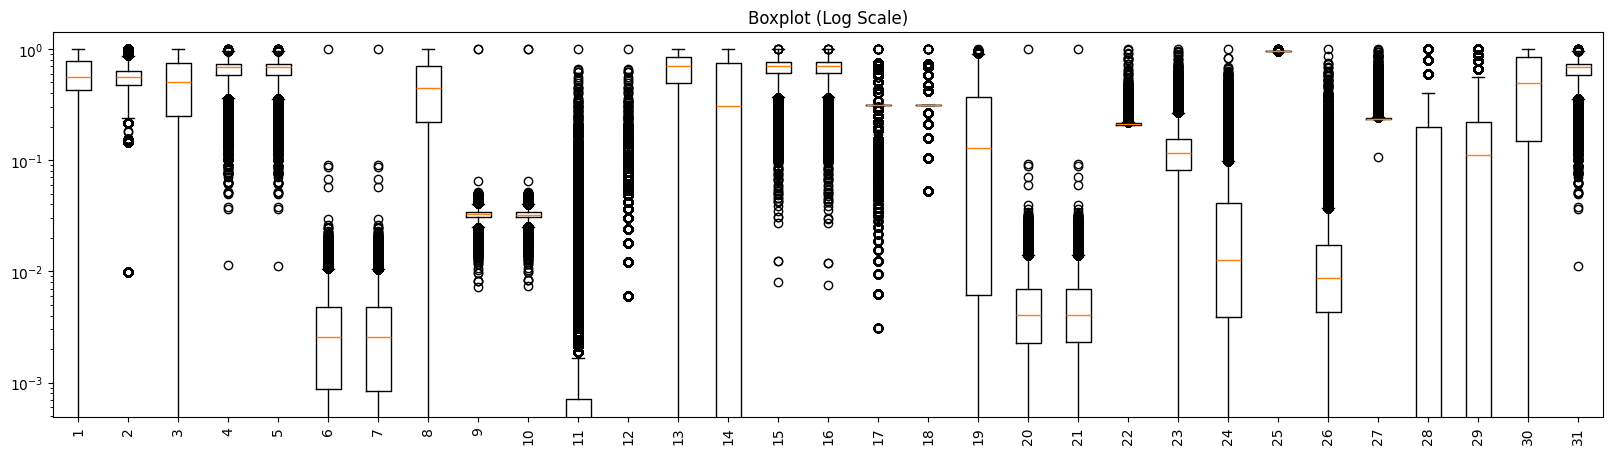

In [15]:
plt.figure(figsize=(20, 5))
plt.boxplot(data.select_dtypes(include='number'))
plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Boxplot (Log Scale)")
plt.show()
